In [137]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [138]:
train_df = pd.read_csv('data/train.csv').drop(columns='id')
test_df = pd.read_csv('data/test.csv')

In [139]:
print(f"Dimensions: {train_df.shape}")
print(f"Null values:\n{train_df.isnull().sum()}")
train_df.describe()

Dimensions: (439140, 15)
Null values:
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64


,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


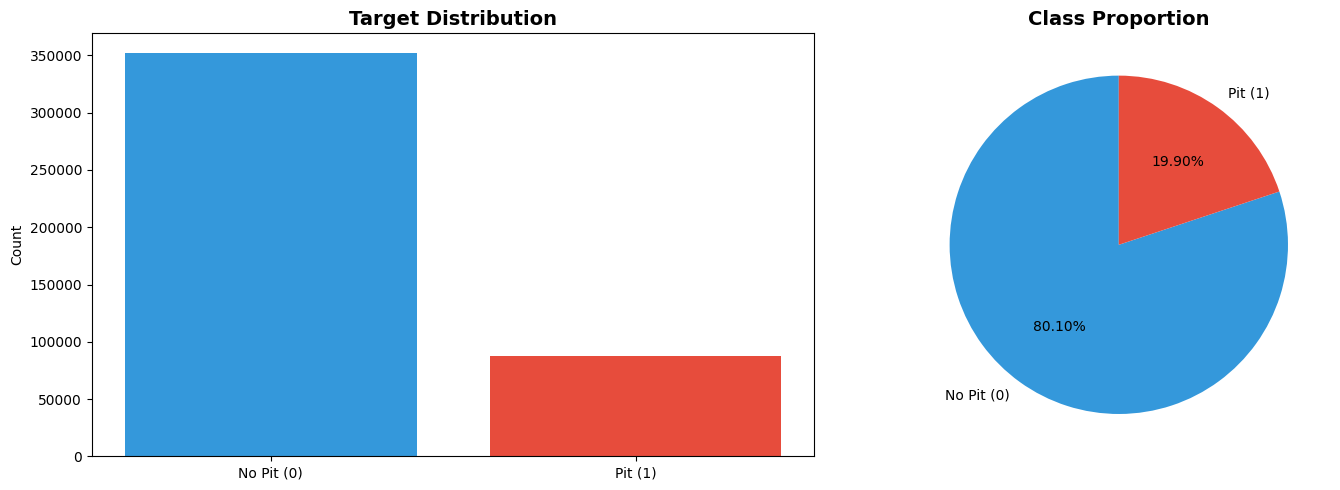

Total: 439,140
No Pit: 351,759 (80.10%)
Pit: 87,381 (19.90%)


In [140]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

target_counts = train_df['PitNextLap'].value_counts()
axes[0].bar(['No Pit (0)', 'Pit (1)'], target_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=['No Pit (0)', 'Pit (1)'], 
            autopct='%1.2f%%', colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Total: {len(train_df):,}")
print(f"No Pit: {target_counts[0]:,} ({target_counts[0]/len(train_df)*100:.2f}%)")
print(f"Pit: {target_counts[1]:,} ({target_counts[1]/len(train_df)*100:.2f}%)")

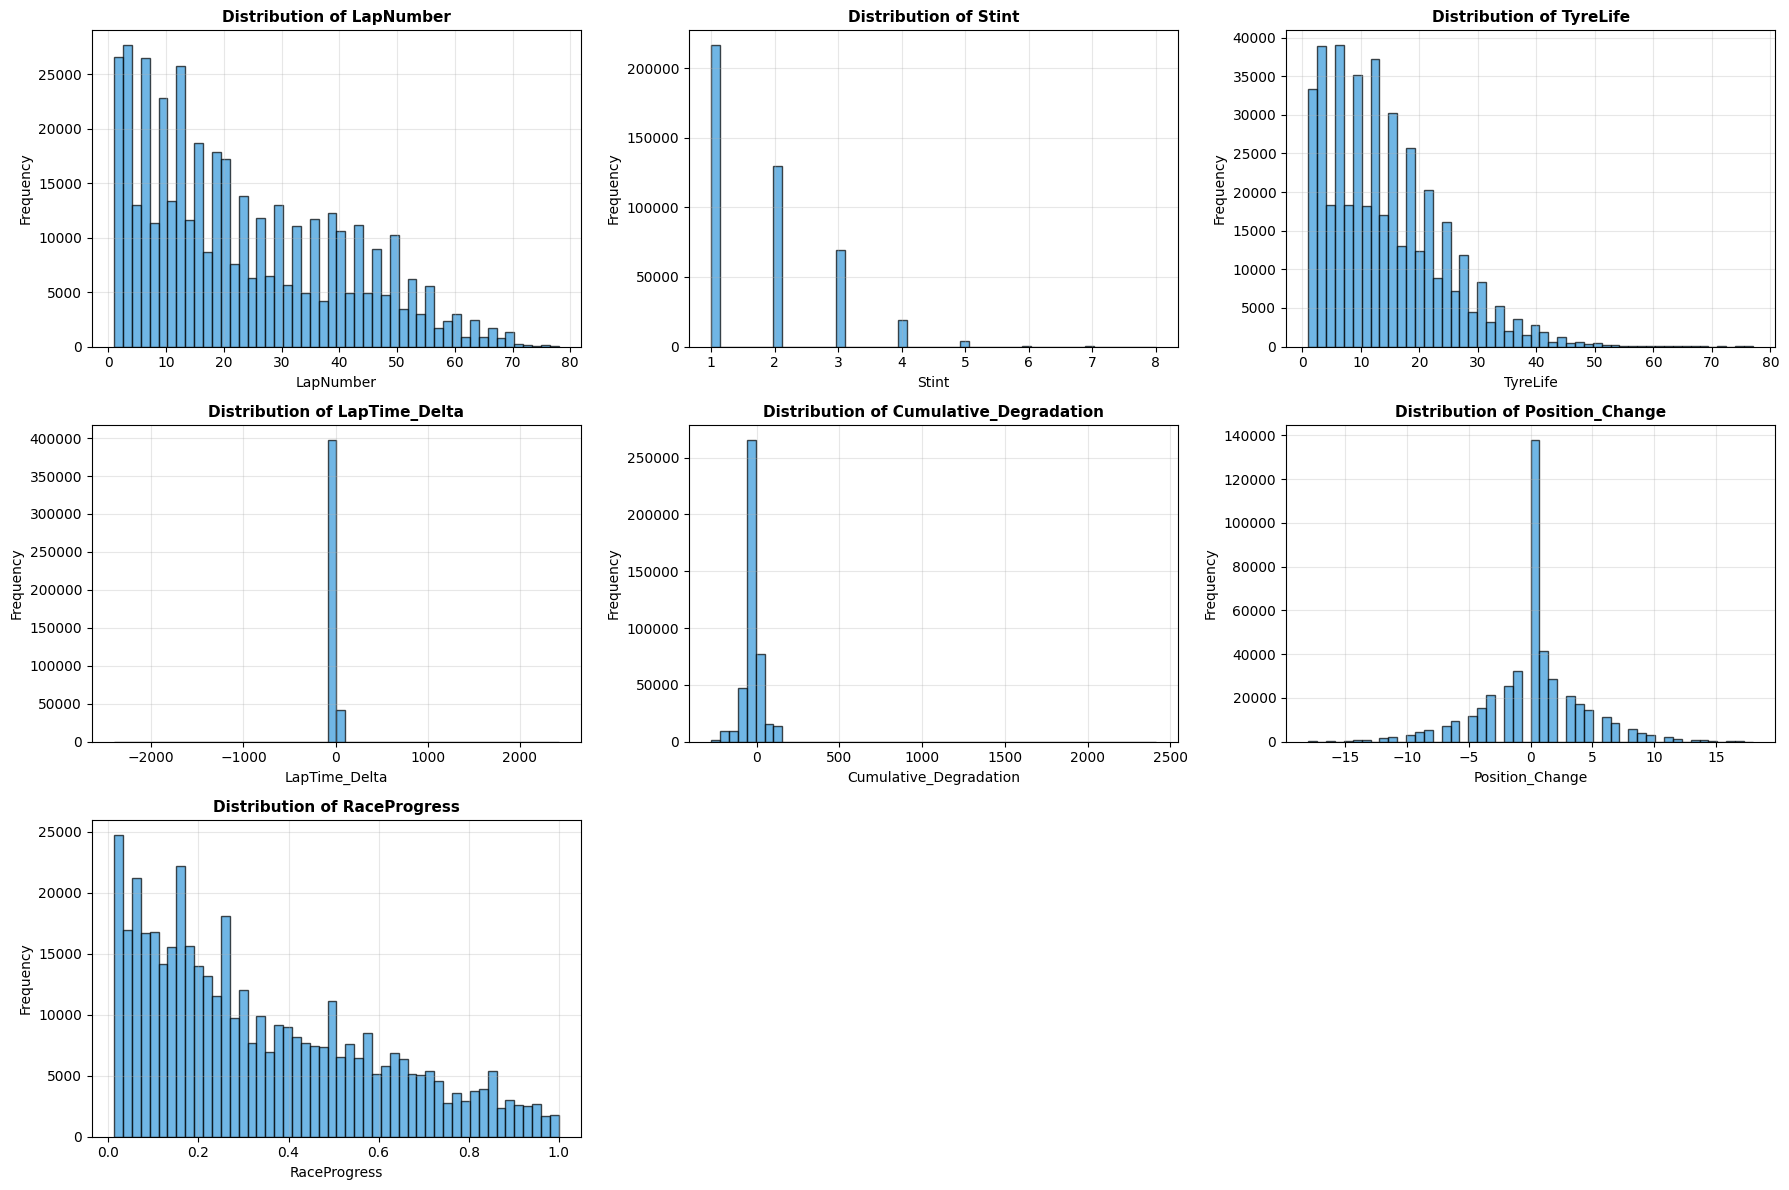

In [141]:
numerical_cols = ['LapNumber', 'Stint', 'TyreLife', 'LapTime_Delta', 
                  'Cumulative_Degradation', 'Position_Change', 'RaceProgress']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if col in train_df.columns:
        axes[idx].hist(train_df[col], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(alpha=0.3)

# Remover subplots vazios
for idx in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

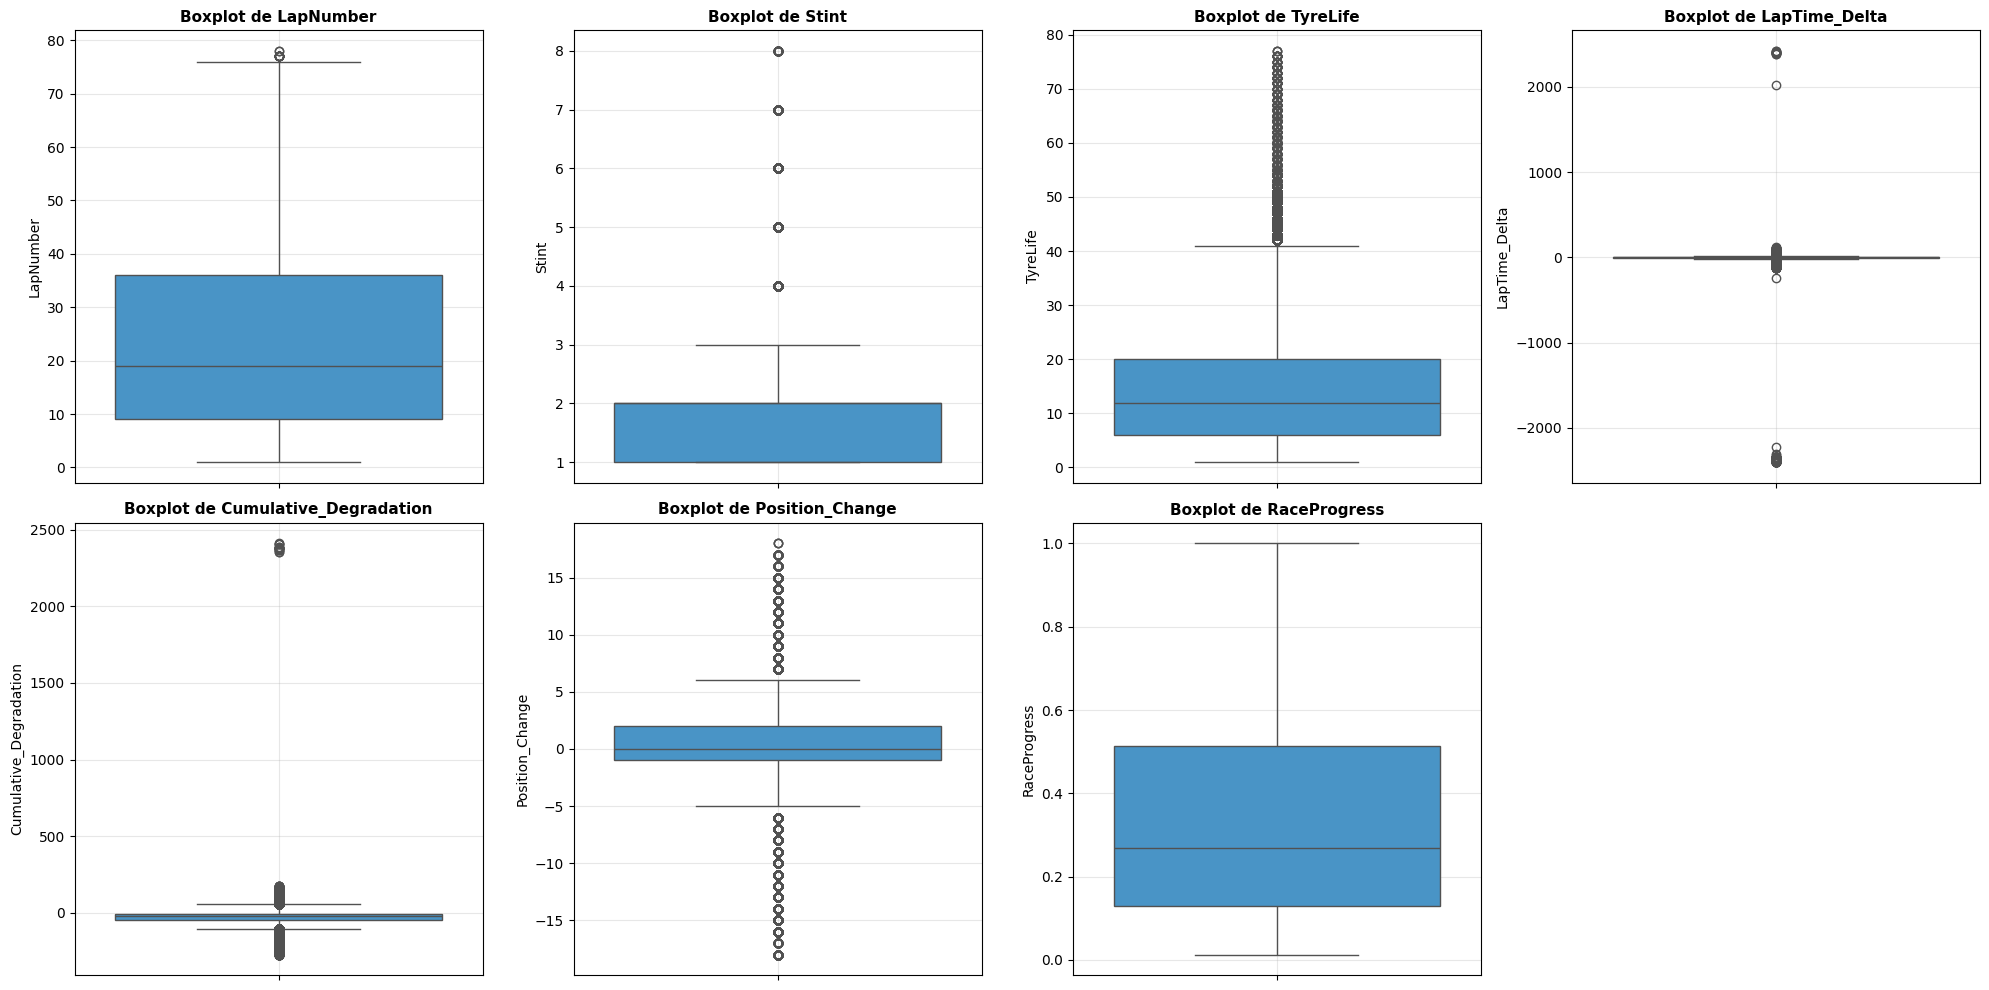

In [142]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if col in train_df.columns:
        sns.boxplot(data=train_df, y=col, ax=axes[idx], color='#3498db')
        axes[idx].set_title(f'Boxplot de {col}', fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)

fig.delaxes(axes[7])
plt.tight_layout()
plt.show()

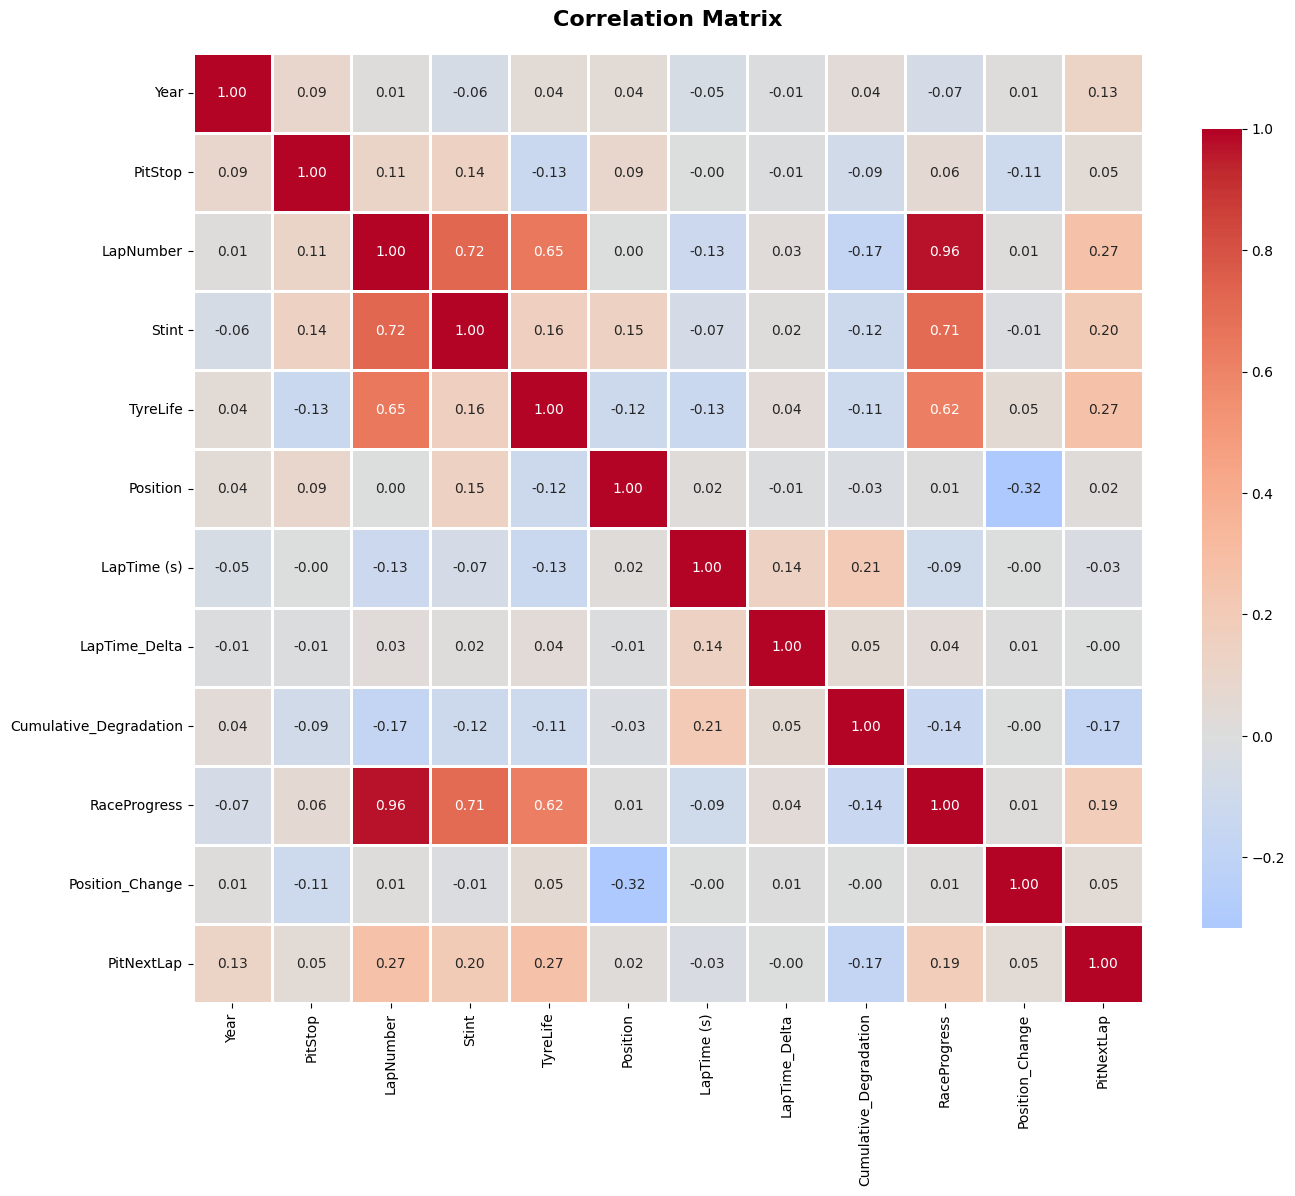

Correlation with PitNextLap:
PitNextLap                1.000000
TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
Position                  0.021348
LapTime_Delta            -0.004946
LapTime (s)              -0.034096
Cumulative_Degradation   -0.167401
Name: PitNextLap, dtype: float64


In [143]:
correlation_matrix = train_df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

if 'PitNextLap' in correlation_matrix.columns:
    target_corr = correlation_matrix['PitNextLap'].sort_values(ascending=False)
    print("Correlation with PitNextLap:")
    print(target_corr)

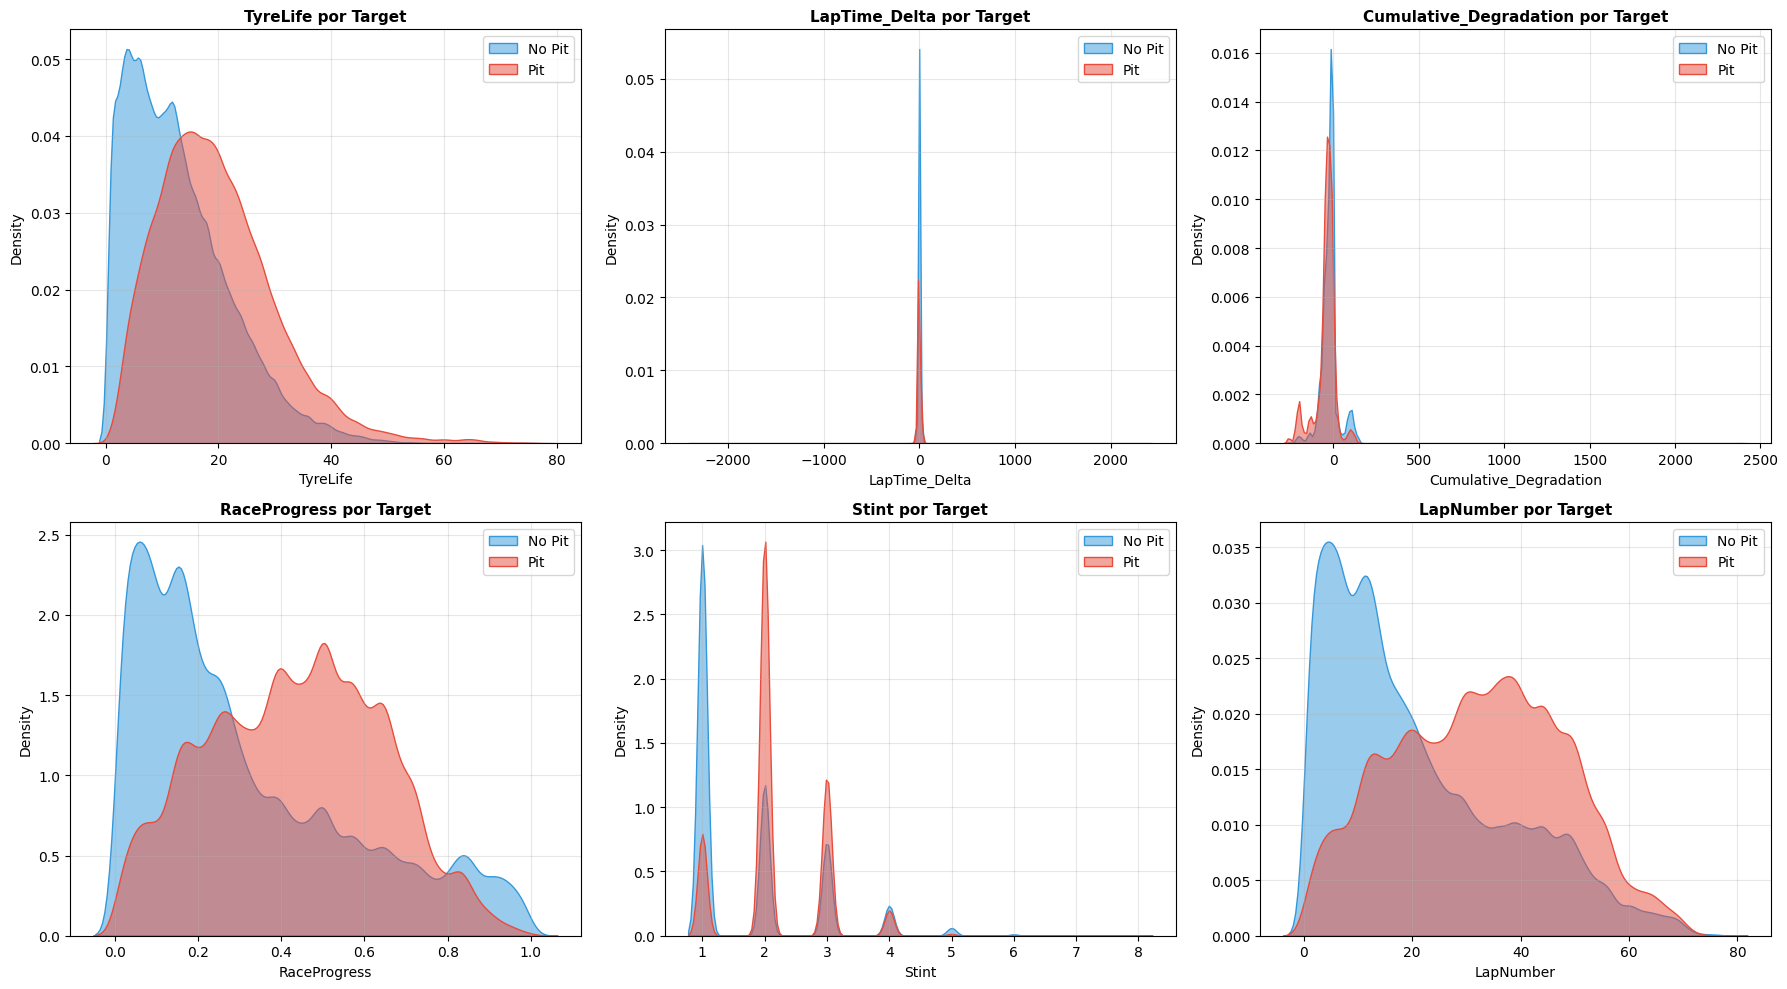

In [144]:
key_features = ['TyreLife', 'LapTime_Delta', 'Cumulative_Degradation', 
                'RaceProgress', 'Stint', 'LapNumber']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    if col in train_df.columns:
        sns.kdeplot(data=train_df[train_df['PitNextLap']==0], x=col, 
                    ax=axes[idx], label='No Pit', fill=True, alpha=0.5, color='#3498db')
        sns.kdeplot(data=train_df[train_df['PitNextLap']==1], x=col, 
                    ax=axes[idx], label='Pit', fill=True, alpha=0.5, color='#e74c3c')
        axes[idx].set_title(f'{col} por Target', fontsize=11, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

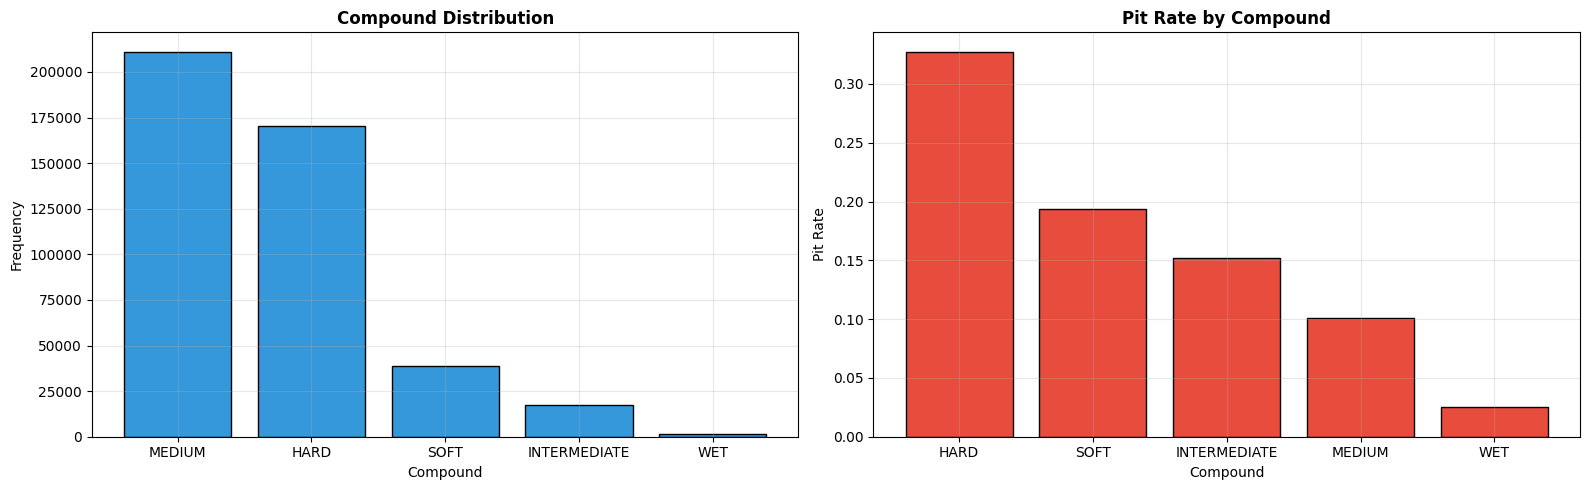

Compound
HARD            0.327537
SOFT            0.193475
INTERMEDIATE    0.152284
MEDIUM          0.101131
WET             0.025092
Name: PitNextLap, dtype: float64


In [145]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

compound_counts = train_df['Compound'].value_counts()
axes[0].bar(compound_counts.index, compound_counts.values, color='#3498db', edgecolor='black')
axes[0].set_title('Compound Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Compound')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

pit_by_compound = train_df.groupby('Compound')['PitNextLap'].mean().sort_values(ascending=False)
axes[1].bar(pit_by_compound.index, pit_by_compound.values, color='#e74c3c', edgecolor='black')
axes[1].set_title('Pit Rate by Compound', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Compound')
axes[1].set_ylabel('Pit Rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(pit_by_compound)

C:\Users\joao.p.mamede.dias\AppData\Local\Temp\ipykernel_31012\148891195.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pit_by_progress = train_df.groupby(pd.cut(train_df['RaceProgress'], bins=20))['PitNextLap'].mean()


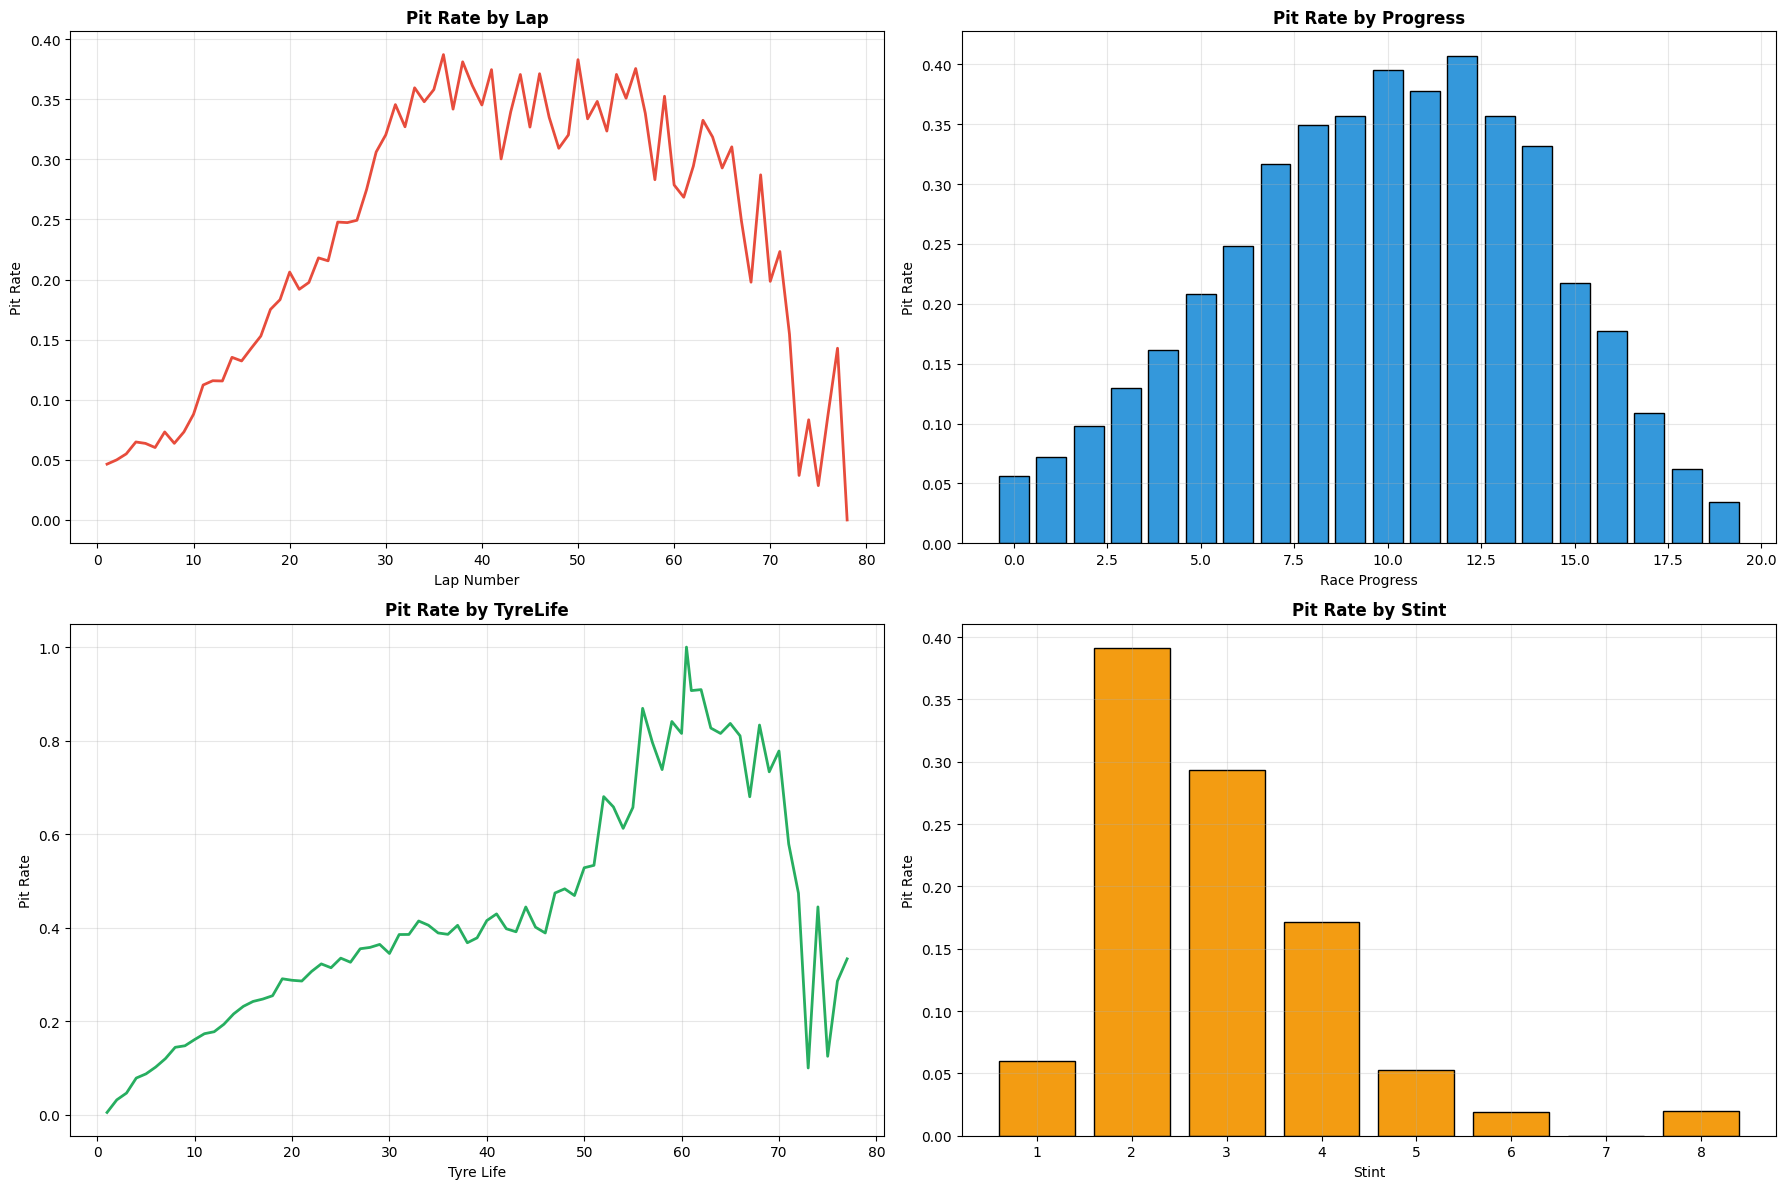

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

pit_by_lap = train_df.groupby('LapNumber')['PitNextLap'].agg(['mean', 'count'])
axes[0, 0].plot(pit_by_lap.index, pit_by_lap['mean'], linewidth=2, color='#e74c3c')
axes[0, 0].set_title('Pit Rate by Lap', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Lap Number')
axes[0, 0].set_ylabel('Pit Rate')
axes[0, 0].grid(alpha=0.3)

pit_by_progress = train_df.groupby(pd.cut(train_df['RaceProgress'], bins=20))['PitNextLap'].mean()
axes[0, 1].bar(range(len(pit_by_progress)), pit_by_progress.values, color='#3498db', edgecolor='black')
axes[0, 1].set_title('Pit Rate by Progress', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Race Progress')
axes[0, 1].set_ylabel('Pit Rate')
axes[0, 1].grid(alpha=0.3)

pit_by_tyrelife = train_df.groupby('TyreLife')['PitNextLap'].mean()
axes[1, 0].plot(pit_by_tyrelife.index, pit_by_tyrelife.values, linewidth=2, color='#27ae60')
axes[1, 0].set_title('Pit Rate by TyreLife', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tyre Life')
axes[1, 0].set_ylabel('Pit Rate')
axes[1, 0].grid(alpha=0.3)

pit_by_stint = train_df.groupby('Stint')['PitNextLap'].mean()
axes[1, 1].bar(pit_by_stint.index, pit_by_stint.values, color='#f39c12', edgecolor='black')
axes[1, 1].set_title('Pit Rate by Stint', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Stint')
axes[1, 1].set_ylabel('Pit Rate')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [147]:
le = LabelEncoder()
scaler = StandardScaler()

In [148]:
train_df.head(10)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0,5,93.734,-9.878,-98.041,0.500000,-3.0,1.0
6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0,11,114.937,-0.181,-11.904,0.333333,0.0,0.0
7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0,1,100.211,-10.292,-53.799,0.569444,0.0,0.0
8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0,12,87.973,10.745,-32.929,0.111111,-9.0,0.0
9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0,8,84.726,-6.669,-6.669,0.028169,0.0,0.0


In [149]:
train_df = train_df.drop(columns='Driver')

<Axes: ylabel='LapTime_Delta'>

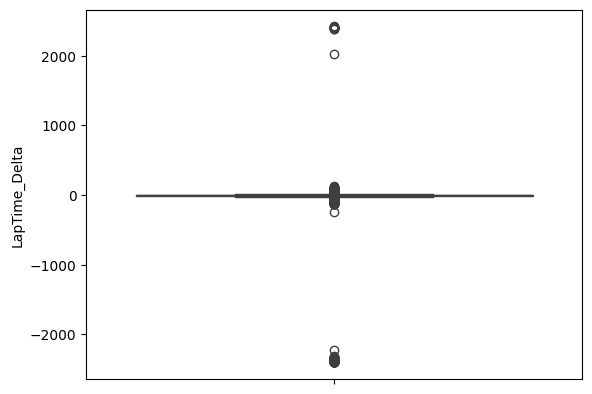

In [150]:
sns.boxplot(train_df['LapTime_Delta'])

In [151]:
train_df = train_df.query('LapTime_Delta <= 1000 & LapTime_Delta >= -200')

<Axes: ylabel='LapTime_Delta'>

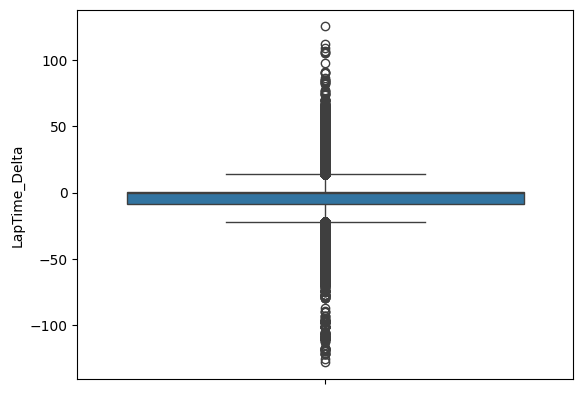

In [152]:
sns.boxplot(train_df['LapTime_Delta'])

In [153]:
train_df['isNegativeDelta'] = (train_df['LapTime_Delta'] < 0).astype(int)

train_df['LapTime_Delta'] = train_df['LapTime_Delta'].abs()

In [154]:
train_df['isNegativeCumulativeDegrad'] = (train_df['Cumulative_Degradation'] < 0).astype(int)

train_df['Cumulative_Degradation'] = train_df['Cumulative_Degradation'].abs()

In [155]:
train_df['isNegativePositionChange'] = (train_df['Position_Change'] < 0).astype(int)

train_df['Position_Change'] = train_df['Position_Change'].abs()

In [156]:
train_df['PitNextLap'] = train_df['PitNextLap'].astype(int)
train_df['Position_Change'] = train_df['Position_Change'].astype(int)
train_df['TyreLife'] = train_df['TyreLife'].astype(int)

In [157]:
race_freq = train_df['Race'].value_counts() / len(train_df)
train_df['Race_Freq'] = train_df['Race'].map(race_freq)
test_df['Race_Freq'] = test_df['Race'].map(race_freq)

train_df = train_df.drop(columns='Race')
test_df = test_df.drop(columns='Race')

In [158]:
train_df.head(10)

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,isNegativeDelta,isNegativeCumulativeDegrad,isNegativePositionChange,Race_Freq
0,HARD,2022,0,50,2,39,8,78.491,7.564,21.019,0.714286,5,1,1,0,0,0.048626
1,HARD,2025,1,27,2,7,4,75.095,32.617,223.207,0.346154,3,0,1,1,1,0.055711
2,HARD,2022,0,59,3,22,13,70.945,7.540,100.529,0.819444,3,1,1,1,0,0.048339
3,MEDIUM,2023,0,2,1,2,7,94.361,7.324,7.324,0.076923,0,0,1,1,0,0.051232
4,HARD,2022,1,26,3,6,2,107.878,8.965,14.139,0.361111,3,0,0,1,0,0.027615
5,HARD,2022,0,35,2,26,5,93.734,9.878,98.041,0.500000,3,1,1,1,1,0.041255
6,MEDIUM,2023,0,23,2,16,11,114.937,0.181,11.904,0.333333,0,0,1,1,0,0.020501
7,HARD,2022,0,41,3,9,1,100.211,10.292,53.799,0.569444,0,0,1,1,0,0.041100
8,MEDIUM,2022,0,4,1,4,12,87.973,10.745,32.929,0.111111,9,0,0,1,1,0.045221
9,MEDIUM,2023,0,2,1,2,8,84.726,6.669,6.669,0.028169,0,0,1,1,0,0.051207


In [159]:
train_df['TyreLife_Squared'] = train_df['TyreLife'] ** 2
train_df['Degradation_Per_Lap'] = train_df['Cumulative_Degradation'] / (train_df['LapNumber'] + 1)

In [160]:
train_df['LapNumber_x_Delta'] = train_df['LapNumber'] * train_df['LapTime_Delta']
train_df['LapNumber_x_RaceFreq'] = train_df['LapNumber'] * train_df['Race_Freq']
train_df['Stint_x_TyreLife'] = train_df['Stint'] * train_df['TyreLife']
train_df['Delta_x_TyreLife'] = train_df['LapTime_Delta'] * train_df['TyreLife']
train_df['Cumulative_Degrad_x_TyreLife'] = train_df['Cumulative_Degradation'] * train_df['TyreLife']

In [161]:
train_df['Is_Mid_Laps'] = train_df['LapNumber'].between(15, 35).astype(int)
train_df['Is_Late_Race'] = (train_df['RaceProgress'] > 0.7).astype(int)

In [162]:
train_df['Critical_TyreLife'] = (train_df['TyreLife'] > 40).astype(int)
train_df['Very_High_TyreLife'] = (train_df['TyreLife'] > 60).astype(int)
train_df['TyreLife_Bucket'] = pd.cut(train_df['TyreLife'], bins=[0, 20, 40, 60, 100], labels=[0, 1, 2, 3]).astype(int)

train_df['Pit_Window'] = train_df['LapNumber'].between(25, 50).astype(int)
train_df['Early_Pit_Zone'] = train_df['LapNumber'].between(10, 25).astype(int)

train_df['High_Risk_Stint'] = (train_df['Stint'] == 2).astype(int)
train_df['Advanced_Stint'] = (train_df['Stint'] >= 3).astype(int)

train_df['Mid_Race_Critical'] = train_df['RaceProgress'].between(0.5, 0.75).astype(int)
train_df['Race_Quarter'] = pd.cut(train_df['RaceProgress'], bins=[0, 0.25, 0.5, 0.75, 1.0], labels=[0, 1, 2, 3]).astype(int)

train_df['TyreLife_x_Stint'] = train_df['TyreLife'] * train_df['Stint']
train_df['TyreLife_x_RaceProgress'] = train_df['TyreLife'] * train_df['RaceProgress']
train_df['LapNumber_x_Stint'] = train_df['LapNumber'] * train_df['Stint']

train_df['TyreLife_per_Stint'] = train_df['TyreLife'] / (train_df['Stint'] + 1)
train_df['Lap_per_Stint'] = train_df['LapNumber'] / (train_df['Stint'] + 1)
train_df['Degrad_per_TyreLife'] = train_df['Cumulative_Degradation'] / (train_df['TyreLife'] + 1)

train_df['Perfect_Pit_Condition'] = ((train_df['TyreLife'] > 40) & (train_df['Pit_Window'] == 1) & (train_df['Mid_Race_Critical'] == 1)).astype(int)
train_df['High_Risk_Combo'] = ((train_df['Critical_TyreLife'] == 1) & (train_df['High_Risk_Stint'] == 1)).astype(int)

In [163]:
train_df.head()

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Mid_Race_Critical,Race_Quarter,TyreLife_x_Stint,TyreLife_x_RaceProgress,LapNumber_x_Stint,TyreLife_per_Stint,Lap_per_Stint,Degrad_per_TyreLife,Perfect_Pit_Condition,High_Risk_Combo
0,HARD,2022,0,50,2,39,8,78.491,7.564,21.019,...,1,2,78,27.857143,100,13.000000,16.666667,0.525475,0,0
1,HARD,2025,1,27,2,7,4,75.095,32.617,223.207,...,0,1,14,2.423077,54,2.333333,9.000000,27.900875,0,0
2,HARD,2022,0,59,3,22,13,70.945,7.540,100.529,...,0,3,66,18.027778,177,5.500000,14.750000,4.370826,0,0
3,MEDIUM,2023,0,2,1,2,7,94.361,7.324,7.324,...,0,0,2,0.153846,2,1.000000,1.000000,2.441333,0,0
4,HARD,2022,1,26,3,6,2,107.878,8.965,14.139,...,0,1,18,2.166667,78,1.500000,6.500000,2.019857,0,0


In [164]:
train_df = train_df.drop_duplicates()
train_df = train_df.dropna()

In [165]:
print(train_df.columns.tolist())
print(train_df.dtypes)

['Compound', 'Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'isNegativeDelta', 'isNegativeCumulativeDegrad', 'isNegativePositionChange', 'Race_Freq', 'TyreLife_Squared', 'Degradation_Per_Lap', 'LapNumber_x_Delta', 'LapNumber_x_RaceFreq', 'Stint_x_TyreLife', 'Delta_x_TyreLife', 'Cumulative_Degrad_x_TyreLife', 'Is_Mid_Laps', 'Is_Late_Race', 'Critical_TyreLife', 'Very_High_TyreLife', 'TyreLife_Bucket', 'Pit_Window', 'Early_Pit_Zone', 'High_Risk_Stint', 'Advanced_Stint', 'Mid_Race_Critical', 'Race_Quarter', 'TyreLife_x_Stint', 'TyreLife_x_RaceProgress', 'LapNumber_x_Stint', 'TyreLife_per_Stint', 'Lap_per_Stint', 'Degrad_per_TyreLife', 'Perfect_Pit_Condition', 'High_Risk_Combo']
Compound                         object
Year                              int64
PitStop                           int64
LapNumber                         int64
Stint                           

In [166]:
train_df['Compound'] = le.fit_transform(train_df['Compound'])

In [167]:
X = train_df.drop(columns='PitNextLap')
y = train_df['PitNextLap']

In [168]:
X_scaled_array = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

In [169]:
X_scaled.head()

,Compound,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,...,Mid_Race_Critical,Race_Quarter,TyreLife_x_Stint,TyreLife_x_RaceProgress,LapNumber_x_Stint,TyreLife_per_Stint,Lap_per_Stint,Degrad_per_TyreLife,Perfect_Pit_Condition,High_Risk_Combo
0,-1.180358,-1.486255,-0.396968,1.585636,0.221652,2.534396,-0.308827,-0.687406,-0.063656,-0.455284,...,2.061181,1.153117,2.040387,2.811919,0.780919,2.009202,1.942663,-0.429126,-0.07858,-0.10099
1,-1.180358,1.440534,2.519094,0.229212,0.221652,-0.730877,-1.066597,-0.875246,2.408471,4.159502,...,-0.485159,0.135602,-0.510517,-0.510110,0.016138,-0.793672,0.277182,3.039183,-0.07858,-0.10099
2,-1.180358,-1.486255,-0.396968,2.116411,1.274011,0.799720,0.638384,-1.104792,-0.066024,1.359471,...,-0.485159,2.170631,1.562092,1.528073,2.061094,0.038431,1.526293,0.058058,-0.07858,-0.10099
3,0.666562,-0.510659,-0.396968,-1.245161,-0.830708,-1.241076,-0.498270,0.190400,-0.087338,-0.767862,...,-0.485159,-0.881912,-0.988811,-0.806502,-0.848396,-1.144032,-1.460712,-0.186398,-0.07858,-0.10099
4,-1.180358,-1.486255,2.519094,0.170238,1.274011,-0.832917,-1.445481,0.938056,0.074589,-0.612315,...,-0.485159,0.135602,-0.351085,-0.543600,0.415154,-1.012647,-0.265910,-0.239796,-0.07858,-0.10099


# -------------------------

# Model Training

In [170]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRFClassifier

In [171]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, random_state=42, test_size=0.2)

## Hyperparameter Tuning - XGBoost

In [172]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 150, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, objective='binary:logistic'),
    param_distributions=param_grid,
    n_iter=20,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here..

In [173]:
best_xgb = xgb_random.best_estimator_
print("Best parameters:", xgb_random.best_params_)
print(f"Best CV score: {xgb_random.best_score_:.4f}")

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV score: 0.9436


### Random Forest Classifier:

In [174]:
RFC_Model = RandomForestClassifier(n_estimators=150, random_state=42)

In [175]:
RFC_Model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [176]:
RFC_y_pred = RFC_Model.predict(X_val)

In [177]:
RFC_roc_auc = roc_auc_score(y_val, RFC_y_pred)
print("Random Forest Classifier's ROC AUC Score: ", RFC_roc_auc)

Random Forest Classifier's ROC AUC Score:  0.8194455696379526


### XGB Classifier:

In [178]:
XGBC_Model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth= 7,
    learning_rate= 0.2,
    gamma= 0.1,
    colsample_bytree= 1.0,
    random_state=42,
    objective='binary:logistic'
)

In [179]:
XGBC_Model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [180]:
XGBC_y_pred = XGBC_Model.predict(X_val)

In [181]:
XGBC_roc_auc = roc_auc_score(y_val, XGBC_y_pred)
print("XGB Classifier's ROC AUC Score: ", XGBC_roc_auc)

XGB Classifier's ROC AUC Score:  0.8326075103563959


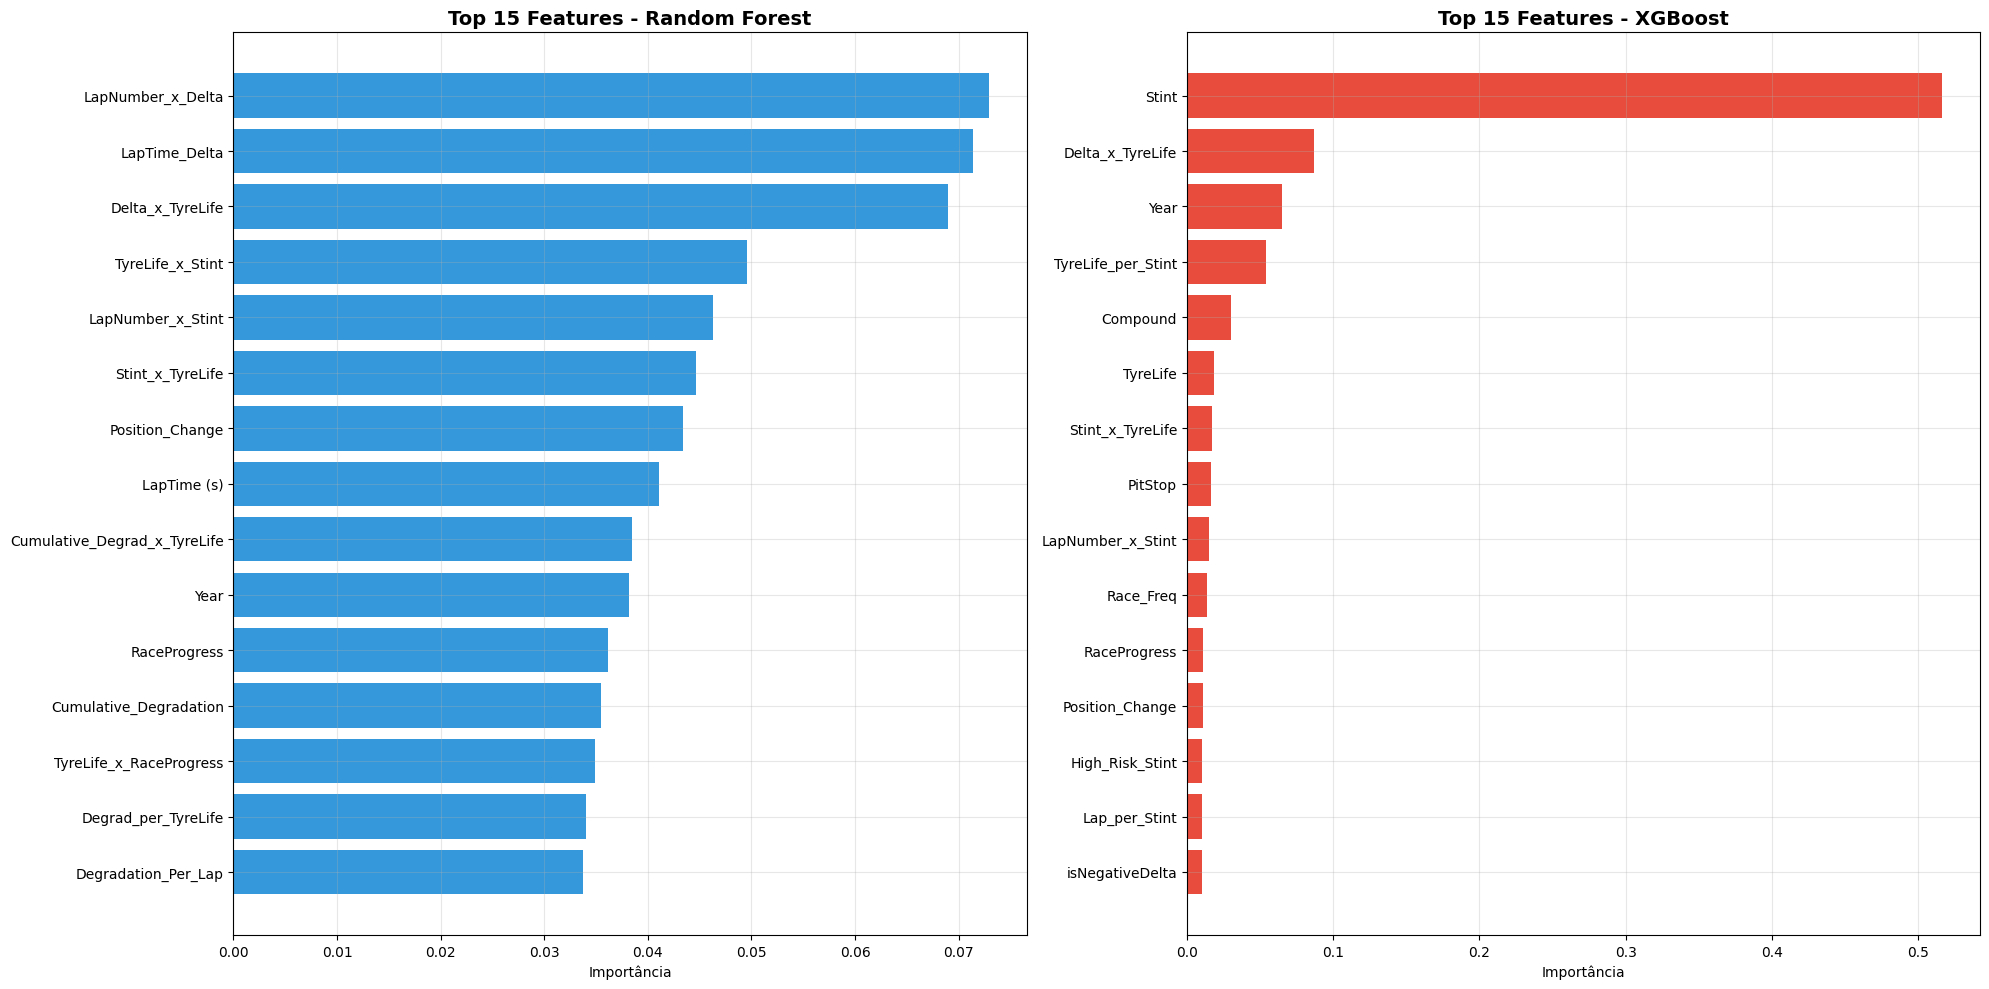

Top 10 - RF:
                         feature  importance
18             LapNumber_x_Delta    0.072915
8                  LapTime_Delta    0.071422
21              Delta_x_TyreLife    0.069008
34              TyreLife_x_Stint    0.049536
36             LapNumber_x_Stint    0.046307
20              Stint_x_TyreLife    0.044631
11               Position_Change    0.043429
7                    LapTime (s)    0.041123
22  Cumulative_Degrad_x_TyreLife    0.038466
1                           Year    0.038138

Top 10 - XGB:
               feature  importance
4                Stint    0.516443
21    Delta_x_TyreLife    0.086722
1                 Year    0.064983
37  TyreLife_per_Stint    0.053819
0             Compound    0.030161
5             TyreLife    0.018555
20    Stint_x_TyreLife    0.017425
2              PitStop    0.016432
36   LapNumber_x_Stint    0.015251
15           Race_Freq    0.014075


In [182]:
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': RFC_Model.feature_importances_
}).sort_values('importance', ascending=False)

xgb_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': XGBC_Model.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

top_rf = rf_importance.head(15)
axes[0].barh(range(len(top_rf)), top_rf['importance'].values, color='#3498db')
axes[0].set_yticks(range(len(top_rf)))
axes[0].set_yticklabels(top_rf['feature'].values)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Features - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importância')
axes[0].grid(alpha=0.3)

top_xgb = xgb_importance.head(15)
axes[1].barh(range(len(top_xgb)), top_xgb['importance'].values, color='#e74c3c')
axes[1].set_yticks(range(len(top_xgb)))
axes[1].set_yticklabels(top_xgb['feature'].values)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Features - XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importância')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 10 - RF:")
print(rf_importance.head(10))
print("\nTop 10 - XGB:")
print(xgb_importance.head(10))

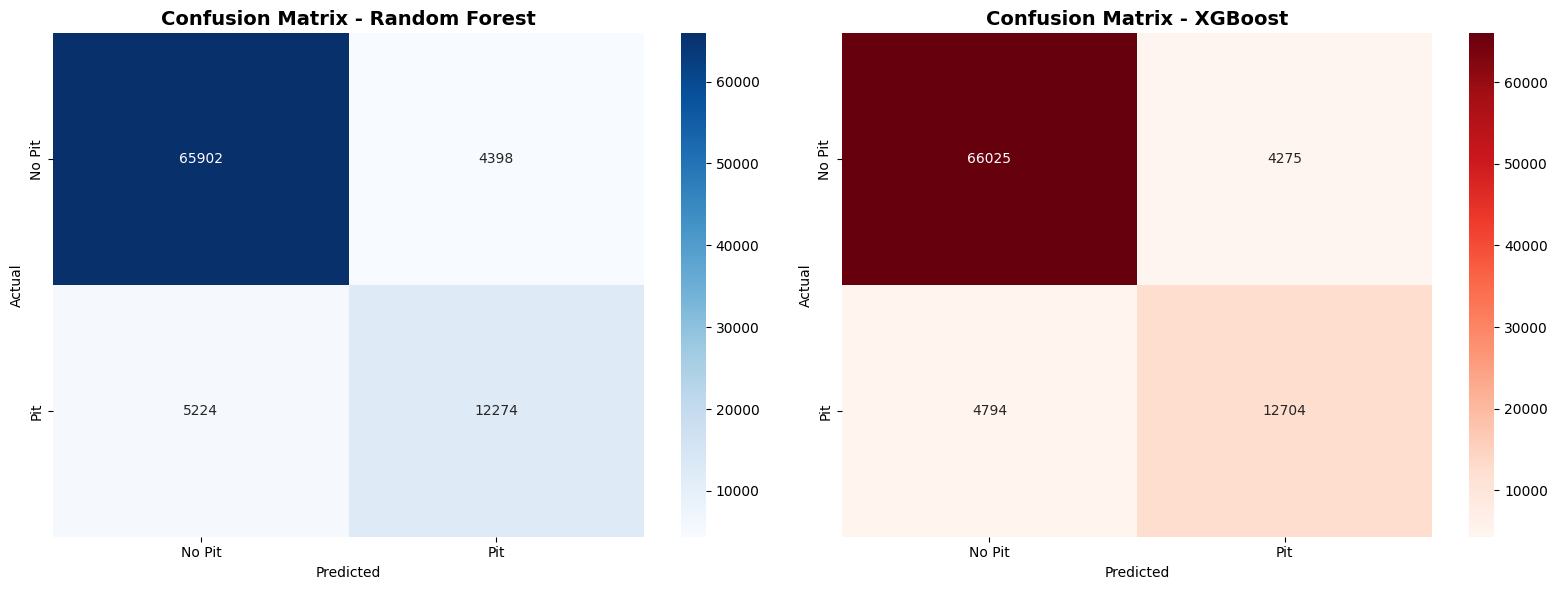

RF:
              precision    recall  f1-score   support

      No Pit       0.93      0.94      0.93     70300
         Pit       0.74      0.70      0.72     17498

    accuracy                           0.89     87798
   macro avg       0.83      0.82      0.83     87798
weighted avg       0.89      0.89      0.89     87798


XGB:
              precision    recall  f1-score   support

      No Pit       0.93      0.94      0.94     70300
         Pit       0.75      0.73      0.74     17498

    accuracy                           0.90     87798
   macro avg       0.84      0.83      0.84     87798
weighted avg       0.90      0.90      0.90     87798



In [183]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_rf = confusion_matrix(y_val, RFC_y_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['No Pit', 'Pit'], yticklabels=['No Pit', 'Pit'])
axes[0].set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_xgb = confusion_matrix(y_val, XGBC_y_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            xticklabels=['No Pit', 'Pit'], yticklabels=['No Pit', 'Pit'])
axes[1].set_title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print("RF:")
print(classification_report(y_val, RFC_y_pred, target_names=['No Pit', 'Pit']))
print("\nXGB:")
print(classification_report(y_val, XGBC_y_pred, target_names=['No Pit', 'Pit']))

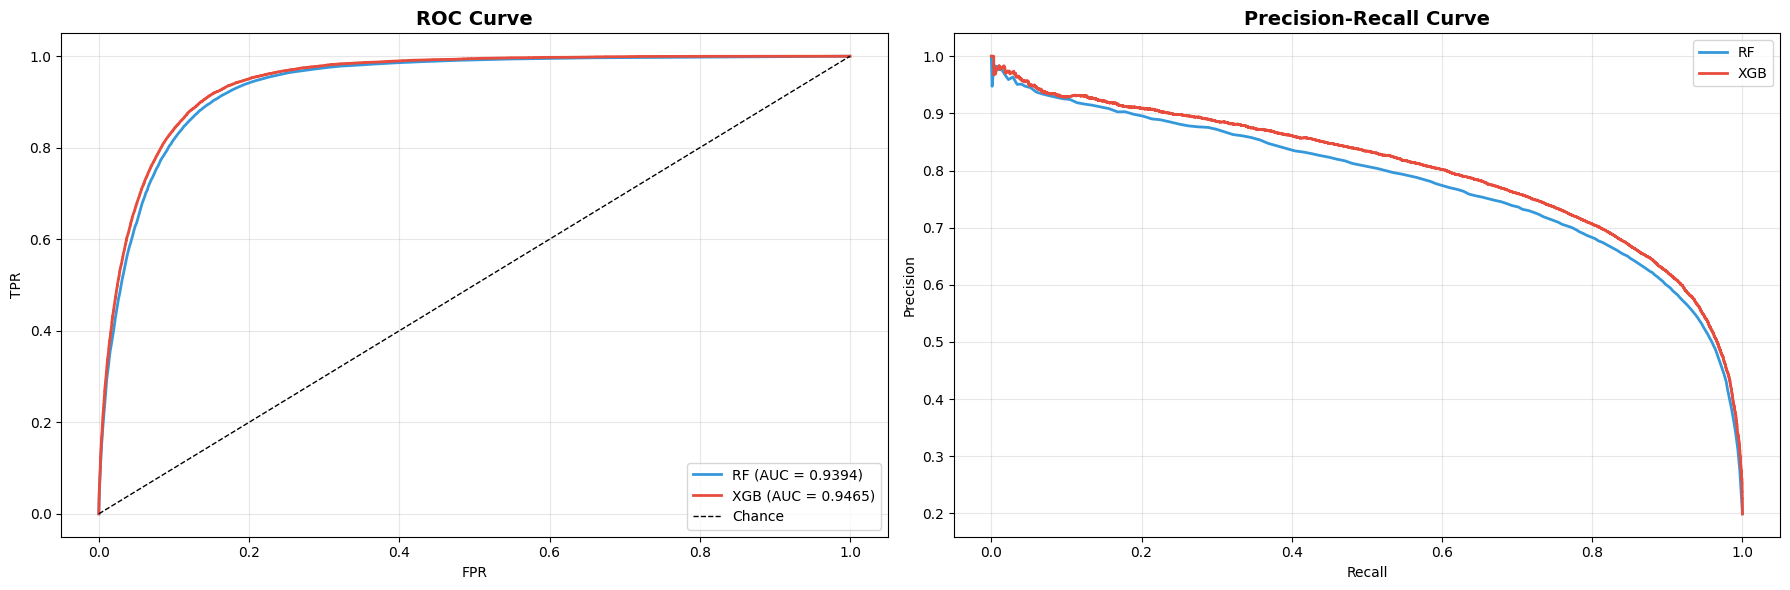

ROC AUC - RF: 0.9394
ROC AUC - XGB: 0.9465


In [184]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

RFC_y_proba = RFC_Model.predict_proba(X_val)[:, 1]
XGBC_y_proba = XGBC_Model.predict_proba(X_val)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_val, RFC_y_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, XGBC_y_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

axes[0].plot(fpr_rf, tpr_rf, color='#3498db', linewidth=2, label=f'RF (AUC = {roc_auc_rf:.4f})')
axes[0].plot(fpr_xgb, tpr_xgb, color='#e74c3c', linewidth=2, label=f'XGB (AUC = {roc_auc_xgb:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Chance')
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend()
axes[0].grid(alpha=0.3)

precision_rf, recall_rf, _ = precision_recall_curve(y_val, RFC_y_proba)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_val, XGBC_y_proba)

axes[1].plot(recall_rf, precision_rf, color='#3498db', linewidth=2, label='RF')
axes[1].plot(recall_xgb, precision_xgb, color='#e74c3c', linewidth=2, label='XGB')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC AUC - RF: {roc_auc_rf:.4f}")
print(f"ROC AUC - XGB: {roc_auc_xgb:.4f}")

# --------------

In [185]:
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

balanced_model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.2,
    gamma=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    objective='binary:logistic'
)

balanced_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,1.0
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [186]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(balanced_model, X_scaled, y, cv=skf, scoring='roc_auc', n_jobs=-1)

print(f"ROC AUC per fold: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

ROC AUC per fold: [0.94579343 0.94518765 0.94489388 0.94414246 0.94535009]
Mean: 0.9451 ± 0.0005


In [187]:
test_ids = test_df['id'].copy()
test_df = test_df.drop(columns=['id', 'Driver'])

In [188]:
test_df['isNegativeDelta'] = (test_df['LapTime_Delta'] < 0).astype(int)
test_df['LapTime_Delta'] = test_df['LapTime_Delta'].abs()

test_df['isNegativeCumulativeDegrad'] = (test_df['Cumulative_Degradation'] < 0).astype(int)
test_df['Cumulative_Degradation'] = test_df['Cumulative_Degradation'].abs()

test_df['isNegativePositionChange'] = (test_df['Position_Change'] < 0).astype(int)
test_df['Position_Change'] = test_df['Position_Change'].abs()

In [189]:
test_df['TyreLife_Squared'] = test_df['TyreLife'] ** 2
test_df['Degradation_Per_Lap'] = test_df['Cumulative_Degradation'] / (test_df['LapNumber'] + 1)
test_df['LapNumber_x_Delta'] = test_df['LapNumber'] * test_df['LapTime_Delta']
test_df['LapNumber_x_RaceFreq'] = test_df['LapNumber'] * test_df['Race_Freq']
test_df['Stint_x_TyreLife'] = test_df['Stint'] * test_df['TyreLife']
test_df['Delta_x_TyreLife'] = test_df['LapTime_Delta'] * test_df['TyreLife']
test_df['Cumulative_Degrad_x_TyreLife'] = test_df['Cumulative_Degradation'] * test_df['TyreLife']
test_df['Is_Mid_Laps'] = test_df['LapNumber'].between(15, 35).astype(int)
test_df['Is_Late_Race'] = (test_df['RaceProgress'] > 0.7).astype(int)

In [190]:
test_df['Critical_TyreLife'] = (test_df['TyreLife'] > 40).astype(int)
test_df['Very_High_TyreLife'] = (test_df['TyreLife'] > 60).astype(int)
test_df['TyreLife_Bucket'] = pd.cut(test_df['TyreLife'], bins=[0, 20, 40, 60, 100], labels=[0, 1, 2, 3]).astype(int)

test_df['Pit_Window'] = test_df['LapNumber'].between(25, 50).astype(int)
test_df['Early_Pit_Zone'] = test_df['LapNumber'].between(10, 25).astype(int)

test_df['High_Risk_Stint'] = (test_df['Stint'] == 2).astype(int)
test_df['Advanced_Stint'] = (test_df['Stint'] >= 3).astype(int)

test_df['Mid_Race_Critical'] = test_df['RaceProgress'].between(0.5, 0.75).astype(int)
test_df['Race_Quarter'] = pd.cut(test_df['RaceProgress'], bins=[0, 0.25, 0.5, 0.75, 1.0], labels=[0, 1, 2, 3]).astype(int)

test_df['TyreLife_x_Stint'] = test_df['TyreLife'] * test_df['Stint']
test_df['TyreLife_x_RaceProgress'] = test_df['TyreLife'] * test_df['RaceProgress']
test_df['LapNumber_x_Stint'] = test_df['LapNumber'] * test_df['Stint']

test_df['TyreLife_per_Stint'] = test_df['TyreLife'] / (test_df['Stint'] + 1)
test_df['Lap_per_Stint'] = test_df['LapNumber'] / (test_df['Stint'] + 1)
test_df['Degrad_per_TyreLife'] = test_df['Cumulative_Degradation'] / (test_df['TyreLife'] + 1)

test_df['Perfect_Pit_Condition'] = ((test_df['TyreLife'] > 40) & (test_df['Pit_Window'] == 1) & (test_df['Mid_Race_Critical'] == 1)).astype(int)
test_df['High_Risk_Combo'] = ((test_df['Critical_TyreLife'] == 1) & (test_df['High_Risk_Stint'] == 1)).astype(int)

In [191]:
test_df['Compound'] = le.transform(test_df['Compound'])

In [192]:
test_df = test_df[X.columns]
test_df_scaled = scaler.transform(test_df)

In [193]:
predictions = balanced_model.predict(test_df_scaled)

submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions
})

submission.to_csv('submission.csv', index=False)

In [194]:
y_pred_val = balanced_model.predict(X_val)
roc_auc_val = roc_auc_score(y_val, y_pred_val)

print(f"Balanced Model ROC AUC (Validation): {roc_auc_val:.4f}")

Balanced Model ROC AUC (Validation): 0.8811


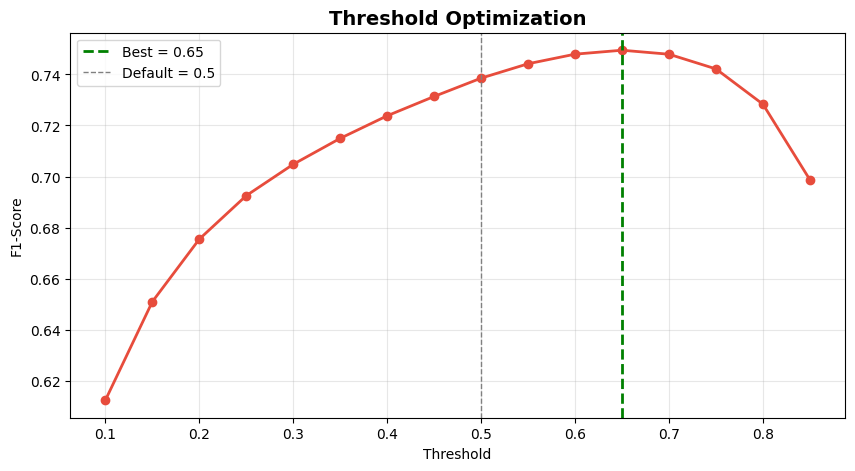

Threshold 0.5:  F1=0.7385
Threshold 0.65: F1=0.7495


In [195]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_proba_val = balanced_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_val >= threshold).astype(int)
    f1 = f1_score(y_val, y_pred_threshold)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, marker='o', linewidth=2, color='#e74c3c')
plt.axvline(x=best_threshold, color='green', linestyle='--', linewidth=2, label=f'Best = {best_threshold:.2f}')
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, label='Default = 0.5')
plt.title('Threshold Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

y_pred_default = (y_proba_val >= 0.5).astype(int)
y_pred_optimized = (y_proba_val >= best_threshold).astype(int)

print(f"Threshold 0.5:  F1={f1_score(y_val, y_pred_default):.4f}")
print(f"Threshold {best_threshold:.2f}: F1={f1_score(y_val, y_pred_optimized):.4f}")

In [196]:
test_proba = balanced_model.predict_proba(test_df_scaled)[:, 1]
predictions_optimized = (test_proba >= best_threshold).astype(int)

submission_optimized = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions_optimized
})

submission_optimized.to_csv('submission_optimized.csv', index=False)
print(f"Submission saved: {len(predictions_optimized):,} predictions")

Submission saved: 188,165 predictions


In [197]:
print(f"Random Forest ROC AUC: {roc_auc_rf:.4f}")
print(f"XGBoost ROC AUC: {roc_auc_xgb:.4f}")
print(f"CV Score: {cv_scores.mean():.4f}")
print(f"Best Threshold: {best_threshold:.2f}")

Random Forest ROC AUC: 0.9394
XGBoost ROC AUC: 0.9465
CV Score: 0.9451
Best Threshold: 0.65


In [199]:
final_model = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth=7,
    learning_rate=0.2,
    gamma=0.1,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    objective='binary:logistic'
)

final_model.fit(X_scaled, y)

predictions_final = final_model.predict(test_df_scaled)

submission_final = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions_final
})

submission_final.to_csv('submission_final.csv', index=False)
print(f"Submission saved: {len(predictions_final):,} predictions")

Submission saved: 188,165 predictions


In [200]:
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.2,
    max_depth=7,
    num_leaves=127,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=1.0,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_scaled, y)

predictions_lgb = lgb_model.predict(test_df_scaled)

submission_lgb = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions_lgb
})

submission_lgb.to_csv('submission_lgb.csv', index=False)
print(f"LightGBM submission saved: {len(predictions_lgb):,} predictions")

c:\Users\joao.p.mamede.dias\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM submission saved: 188,165 predictions


In [201]:
lgb_model_v2 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,
    num_leaves=150,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

lgb_model_v2.fit(X_scaled, y)

predictions_lgb_v2 = lgb_model_v2.predict(test_df_scaled)

submission_lgb_v2 = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions_lgb_v2
})

submission_lgb_v2.to_csv('submission_lgb_v2.csv', index=False)
print(f"LightGBM v2 submission saved: {len(predictions_lgb_v2):,} predictions")

c:\Users\joao.p.mamede.dias\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM v2 submission saved: 188,165 predictions


In [202]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=0
)

catboost_model.fit(X_scaled, y)

predictions_catboost = catboost_model.predict(test_df_scaled)

submission_catboost = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': predictions_catboost
})

submission_catboost.to_csv('submission_catboost.csv', index=False)
print(f"CatBoost submission saved: {len(predictions_catboost):,} predictions")

CatBoost submission saved: 188,165 predictions
